

1) Le premier script  implémente deux modèles financiers distincts pour estimer le risque de défaut d'un portefeuille de crédits : le modèle AJD (Affine Jump-Diffusion, basé sur des simulations de Monte Carlo) et le modèle LHP (Large Homogeneous Portfolio, le standard du marché). 

    À partir de données historiques réelles, ce moteur cherche à calibrer les modèles en trouvant les paramètres qui reproduisent le plus fidèlement les prix du marché pour les tranches Equity, Mezzanine et Senior. Il évalue ensuite cette précision en calculant la marge d'erreur (RMSE).

2) Le second script est entièrement dédié à la visualisation des résultats à l'aide de Matplotlib. Il génère des graphiques de spreads permettant de comparer visuellement les prix réels avec les estimations du modèle AJD au fil du temps. Enfin, un graphique en barres illustre l'erreur de calibration, offrant une comparaison claire et directe de la performance entre les modèles AJD et LHP sur les différentes dates analysées.

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

PORTFOLIO = dict(N=125, R=0.40, LGD=0.60, r=0.0014, T=5.0, freq=4)

AJD_PARAMS = dict(kappa=0.50, theta=0.02, sigma=0.10, xi=0.10, mu_J=0.05, lambda0=0.02)

MC_PARAMS = dict(M=5000, dt=1/52, seed=42)

BETA_GRID = np.linspace(0.01, 2.0, 80)

TRANCHES = [
    dict(name="Equity", K_lo=0.00, K_hi=0.03),
    dict(name="Mezz1", K_lo=0.03, K_hi=0.07),
    dict(name="Mezz2", K_lo=0.07, K_hi=0.15),
    dict(name="Senior", K_lo=0.15, K_hi=1.00),
]

MARKET_DATA = pd.DataFrame([
    ("2014-06-01", 0.4250, 200.0, 3.6, 1.4, 39),
    ("2014-07-03", 0.3750, 137.5, 4.8, 1.5, 37),
    ("2014-08-15", 0.4094, 171.9, 5.0, 1.4, 38),
    ("2014-09-23", 0.3750, 137.5, 5.6, 1.2, 37),
    ("2014-10-11", 0.5775, 181.0, 5.0, 1.2, 41),
    ("2014-11-17", 0.4188, 98.5, 5.7, 1.5, 35),
    ("2014-12-01", 0.3183, 74.7, 6.0, 1.6, 32),
    ("2015-01-07", 0.7065, 87.5, 5.5, 1.3, 39),
    ("2015-02-10", 0.7559, 56.3, 5.5, 1.4, 37),
    ("2015-03-15", 0.6874, 7.3, 6.4, 1.5, 34),
], columns=["date", "equity_upfront", "mezz1_bps", "mezz2_bps", "senior_bps", "cds_bps"])

MARKET_DATA["date"] = pd.to_datetime(MARKET_DATA["date"])


def ajd_mean_stationary(params):
    return params['theta'] + params['xi'] * params['mu_J'] / params['kappa']


def simulate_ajd_paths(params, T, dt, M, seed=42):
    rng = np.random.default_rng(seed)
    n_steps = int(np.round(T / dt))
    time_grid = np.linspace(0.0, T, n_steps + 1)

    paths = np.zeros((M, n_steps + 1))
    paths[:, 0] = params['lambda0']

    for t in range(n_steps):
        lam = paths[:, t]
        Z = rng.standard_normal(M)

        drift = params['kappa'] * (params['theta'] - lam) * dt
        diffusion = params['sigma'] * np.sqrt(np.maximum(lam, 0)) * np.sqrt(dt) * Z

        n_jumps = rng.poisson(params['xi'] * dt, size=M)
        jump = np.zeros(M)
        for k in range(1, int(n_jumps.max()) + 1):
            mask = n_jumps >= k
            jump[mask] += rng.exponential(params['mu_J'], size=mask.sum())

        paths[:, t + 1] = np.maximum(lam + drift + diffusion + jump, 0)

    return paths, time_grid


def compute_loss_distribution(Lambda, N, LGD, seed=123):
    rng = np.random.default_rng(seed)
    p = 1 - np.exp(-Lambda)
    U = rng.uniform(0, 1, (len(Lambda), N))
    defaults = (U < p[:, None]).sum(axis=1)
    return LGD * defaults / N


def tranche_loss(L, K1, K2):
    return np.clip(L - K1, 0, K2 - K1) / (K2 - K1)


def price_tranche_ajd(loss, K1, K2, r, T, freq, equity=False):
    tl = tranche_loss(loss, K1, K2).mean()
    PV = tl * np.exp(-r * T)

    times = np.arange(1, int(T * freq) + 1) * T / (T * freq)
    ann = np.sum(np.exp(-r * times) * (1 - tl * times / T)) * (T / (T * freq))

    if equity:
        return PV - 0.05 * ann
    return 0 if ann < 1e-12 else (PV / ann) * 10000


def lhp_default_prob(s, LGD, r, T):
    return 1 - np.exp(-(s / LGD) * T)


def gaussian_copula_lhp_tranche(rho, p, K1, K2, LGD):
    from numpy.polynomial.hermite import hermgauss
    x, w = hermgauss(80)
    m = x * np.sqrt(2)
    w = w / np.sqrt(np.pi)

    arg = (norm.ppf(p) - np.sqrt(rho) * m) / np.sqrt(1 - rho)
    L = LGD * norm.cdf(np.clip(arg, -8, 8))
    tl = np.clip(L - K1, 0, K2 - K1) / (K2 - K1)
    return np.dot(tl, w)


def price_tranche_lhp(rho, p, K1, K2, LGD, r, T, freq, equity=False):
    tl = gaussian_copula_lhp_tranche(rho, p, K1, K2, LGD)
    PV = tl * np.exp(-r * T)

    times = np.arange(1, int(T * freq) + 1) * T / (T * freq)
    ann = np.sum(np.exp(-r * times) * (1 - tl * times / T)) * (T / (T * freq))

    if equity:
        return PV - 0.05 * ann
    return 0 if ann < 1e-12 else (PV / ann) * 10000


def rmse_log(model, row):
    mkt = [row['equity_upfront'], row['mezz1_bps']*1e-4, row['mezz2_bps']*1e-4, row['senior_bps']*1e-4]
    return np.sqrt(np.mean([(np.log(a/b)**2 if a>1e-8 and b>1e-8 else 25) for a,b in zip(model,mkt)]))


def calibrate_single_date(row):
    paths, grid = simulate_ajd_paths(AJD_PARAMS, PORTFOLIO['T'], MC_PARAMS['dt'], MC_PARAMS['M'])

    dt = np.diff(grid)
    integral = np.sum(0.5*(paths[:,:-1]+paths[:,1:])*dt, axis=1)

    best = (None, None, np.inf, None)

    for beta in BETA_GRID:
        lidio = row['cds_bps']*1e-4/PORTFOLIO['LGD'] - beta*ajd_mean_stationary(AJD_PARAMS)
        if lidio < 0: continue

        L = compute_loss_distribution(lidio*PORTFOLIO['T'] + beta*integral, PORTFOLIO['N'], PORTFOLIO['LGD'])

        spreads = []
        for i,tr in enumerate(TRANCHES):
            v = price_tranche_ajd(L, tr['K_lo'], tr['K_hi'], PORTFOLIO['r'], PORTFOLIO['T'], PORTFOLIO['freq'], i==0)
            spreads.append(v if i==0 else v*1e-4)

        err = rmse_log(spreads, row)
        if err < best[2]:
            best = (beta, lidio, err, spreads)

    return dict(date=row['date'], beta_opt=best[0], lidio_opt=best[1], rmse_log=best[2], spreads_model=best[3])


def calibrate_lhp_single_date(row):
    p = lhp_default_prob(row['cds_bps']*1e-4, PORTFOLIO['LGD'], PORTFOLIO['r'], PORTFOLIO['T'])

    best = (None, np.inf)
    for rho in np.linspace(0.01,0.99,99):
        spreads = []
        for i,tr in enumerate(TRANCHES):
            v = price_tranche_lhp(rho, p, tr['K_lo'], tr['K_hi'], PORTFOLIO['LGD'], PORTFOLIO['r'], PORTFOLIO['T'], PORTFOLIO['freq'], i==0)
            spreads.append(v if i==0 else v*1e-4)

        err = rmse_log(spreads, row)
        if err < best[1]:
            best = (rho, err)

    return dict(date=row['date'], rho_opt=best[0], rmse_log=best[1])


if __name__ == "__main__":
    results_ajd = [calibrate_single_date(r) for _,r in MARKET_DATA.iterrows()]
    results_lhp = [calibrate_lhp_single_date(r) for _,r in MARKET_DATA.iterrows()]

    spreads_ajd_equity = [r['spreads_model'][0] for r in results_ajd]
    spreads_ajd_mezz1  = [r['spreads_model'][1]*10000 for r in results_ajd]
    spreads_ajd_mezz2  = [r['spreads_model'][2]*10000 for r in results_ajd]
    spreads_ajd_senior = [r['spreads_model'][3]*10000 for r in results_ajd]

    print("spreads_ajd =", spreads_ajd_equity)

    spreads_lhp_equity, spreads_lhp_mezz1, spreads_lhp_mezz2, spreads_lhp_senior = [],[],[],[]
    rmse_lhp_list, rho_opt_list = [], []

    for res, (_, row) in zip(results_lhp, MARKET_DATA.iterrows()):
        rho = res['rho_opt']
        p = lhp_default_prob(row['cds_bps']*1e-4, PORTFOLIO['LGD'], PORTFOLIO['r'], PORTFOLIO['T'])

        spreads = []
        for i,tr in enumerate(TRANCHES):
            v = price_tranche_lhp(rho, p, tr['K_lo'], tr['K_hi'], PORTFOLIO['LGD'], PORTFOLIO['r'], PORTFOLIO['T'], PORTFOLIO['freq'], i==0)
            spreads.append(v if i==0 else v*1e-4)

        spreads_lhp_equity.append(spreads[0])
        spreads_lhp_mezz1.append(spreads[1]*10000)
        spreads_lhp_mezz2.append(spreads[2]*10000)
        spreads_lhp_senior.append(spreads[3]*10000)

        rmse_lhp_list.append(res['rmse_log'])
        rho_opt_list.append(rho)

    print("spreads_lhp =", spreads_lhp_equity)

spreads_ajd = [np.float64(0.311778871338576), np.float64(0.29921198857898995), np.float64(0.3151318379117704), np.float64(0.29921198857898995), np.float64(0.3420274839895113), np.float64(0.268100414021817), np.float64(0.23836418500271045), np.float64(0.311778871338576), np.float64(0.29921198857898995), np.float64(0.2526210348286787)]
spreads_lhp = [np.float64(0.24141290556189626), np.float64(0.21690221482410316), np.float64(0.23379858454698552), np.float64(0.22389671925949578), np.float64(0.2706410314853383), np.float64(0.19090197185018337), np.float64(0.1505151541112481), np.float64(0.24856802353160706), np.float64(0.22389671925949578), np.float64(0.18791057203234568)]


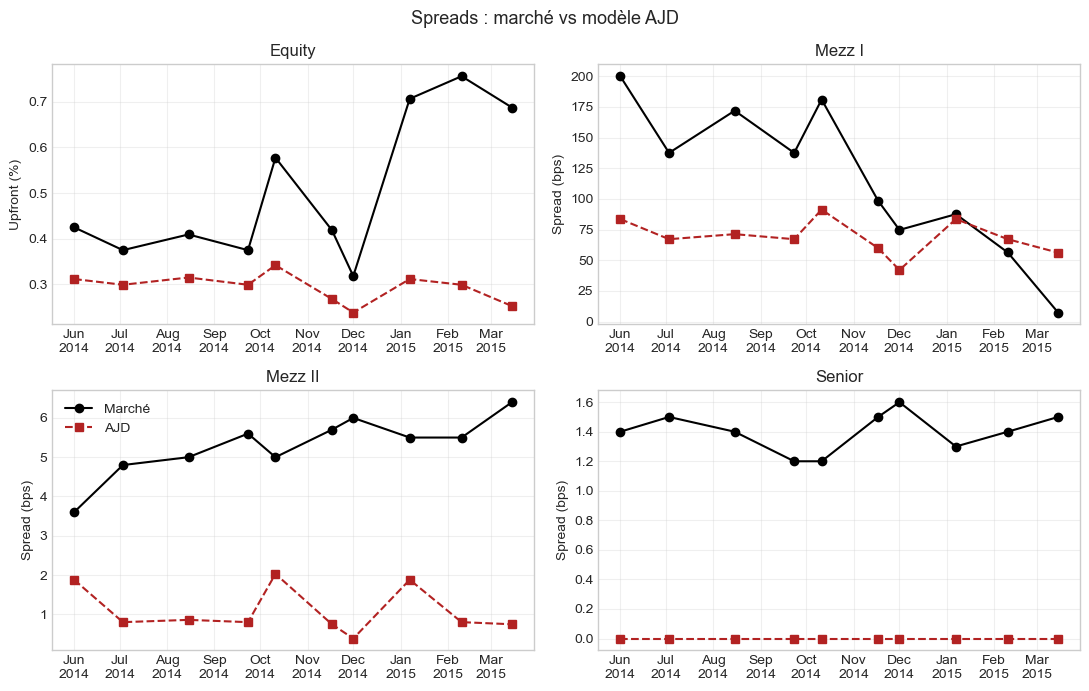

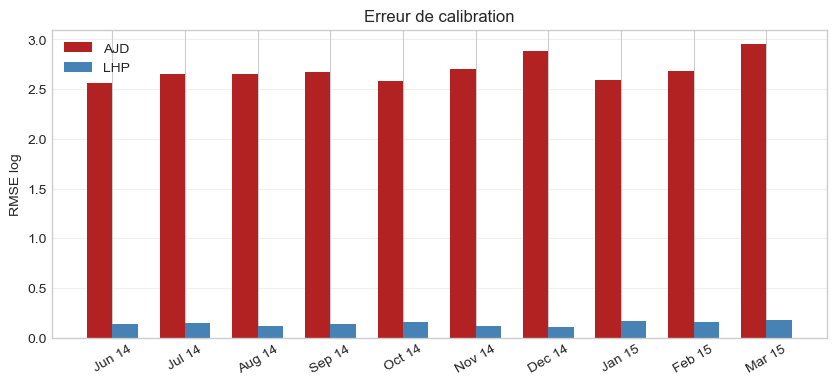

In [31]:
"""
Comparaison simple : Marché vs modèle AJD
CDX NA IG S19 – T = 5 ans
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ─────────────────────────────────────────────
# Données
# ─────────────────────────────────────────────

dates = pd.to_datetime([
    "2014-06-01","2014-07-03","2014-08-15","2014-09-23","2014-10-11",
    "2014-11-17","2014-12-01","2015-01-07","2015-02-10","2015-03-15"
])

marche = {
    "Equity":  np.array([0.4250,0.3750,0.4094,0.3750,0.5775,0.4188,0.3183,0.7065,0.7559,0.6874]),
    "Mezz I":  np.array([200,137.5,171.9,137.5,181,98.5,74.7,87.5,56.3,7.3]),
    "Mezz II": np.array([3.6,4.8,5.0,5.6,5.0,5.7,6.0,5.5,5.5,6.4]),
    "Senior":  np.array([1.4,1.5,1.4,1.2,1.2,1.5,1.6,1.3,1.4,1.5]),
}

ajd = {
    "Equity":  spreads_ajd_equity,
    "Mezz I":  spreads_ajd_mezz1,
    "Mezz II": spreads_ajd_mezz2,
    "Senior":  spreads_ajd_senior,
}

 
# ─────────────────────────────────────────────
# Figure 1 : spreads
# ─────────────────────────────────────────────

def plot_spreads():
    fig, axes = plt.subplots(2, 2, figsize=(11,7))
    axes = axes.flatten()

    noms = ["Equity","Mezz I","Mezz II","Senior"]

    for i, key in enumerate(noms):
        ax = axes[i]

        ax.plot(dates, marche[key], "o-", label="Marché", color="black")
        ax.plot(dates, ajd[key], "s--", label="AJD", color="firebrick")

        ax.set_title(key)

        if key == "Equity":
            ax.set_ylabel("Upfront (%)")
        else:
            ax.set_ylabel("Spread (bps)")

        ax.grid(alpha=0.3)

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
        ax.tick_params(axis="x", rotation=0)

        if i == 2:
            ax.legend()

    fig.suptitle("Spreads : marché vs modèle AJD", fontsize=13)
    plt.tight_layout()
    return fig


# ─────────────────────────────────────────────
# Figure 2 : RMSE
# ─────────────────────────────────────────────

def plot_rmse():
    fig, ax = plt.subplots(figsize=(10,4))

    x = np.arange(len(dates))
    w = 0.35

    ax.bar(x - w/2, rmse_ajd, w, label="AJD", color="firebrick")
    ax.bar(x + w/2, rmse_lhp, w, label="LHP", color="steelblue")

    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%b %y") for d in dates], rotation=30)

    ax.set_ylabel("RMSE log")
    ax.set_title("Erreur de calibration")

    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    return fig


# ─────────────────────────────────────────────
# Lancement
# ─────────────────────────────────────────────

if __name__ == "__main__":
    plot_spreads()
    plot_rmse()
    plt.show()